# Benchmarki

# Symulowana Bifurkacja


In [14]:
# Obliczenia potrzebne do benchmarku

import os
import time
import pickle

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

from funkcje_pomocnicze import read_instance, instance
from benchmarks import discrete_simulated_bifurcation_gpu, discrete_simulated_bifurcation, discrete_simulated_bifurcation_gpu_naive
from IPython.utils.io import capture_output
from tqdm import tqdm

P2 = instance(os.path.join("instancje", "Pegasus", "P2_CBFM-P.txt"), -39.0)
P4 = instance(os.path.join("instancje", "Pegasus", "P4_CBFM-P.txt"), -469.0)
P8 = instance(os.path.join("instancje", "Pegasus", "P8_CBFM-P.txt"), -2752.0)
P12 = instance(os.path.join("instancje", "Pegasus", "P12_CBFM-P.txt"), -6831.0)
P16 = instance(os.path.join("instancje", "Pegasus", "P16_CBFM-P.txt"), -12772.0)  



functions = [discrete_simulated_bifurcation_gpu]
pegasus= [P2, P4, P8, P12, P16]
zephyr = []

global_results = []
for function in functions:
    gaps = []
    times = []
    for instance in tqdm(pegasus):
        J, h = read_instance(instance.path, convention="minus_half")
        J2 = cp.asarray(J, dtype=cp.float32)
        h2 = cp.asarray(h, dtype=cp.float32)
        # kompilacja 
        with capture_output() as captured:
            states, energies = function(J2, h2, 100, 0.25, 2**5)

        result = 0
        elapsed = 0
        count = 0
        best_result = 0
        start = time.time()
        while result != instance.best_energy :
            with capture_output() as captured:
                states, energies = function(J2, h2, 1000 * (1 + count), 0.5, 2**(10 + max(count, 5)), c_0_scaling=0.7)
            result = min(energies).item()
            
            if result < best_result:
                best_result = result

            checkpoint = time.time()
            elapsed = checkpoint - start
            gap = (instance.best_energy - best_result)/instance.best_energy

            if elapsed >= 60:
                if gap < 0.01:
                    break
            count += 1
                
        gaps.append((instance.best_energy - best_result)/instance.best_energy)    
        print(gaps)  
        times.append(elapsed)
        print(times)


with open(os.path.join("wyniki", "sbm_pegasus_results.pkl"), "wb") as f:
    data = (times, gaps)
    pickle.dump(data, f)



 20%|██        | 1/5 [00:12<00:48, 12.23s/it]

[-0.0]
[1.1795628070831299]


 40%|████      | 2/5 [00:15<00:20,  6.72s/it]

[-0.0, -0.0]
[1.1795628070831299, 2.8318285942077637]


 60%|██████    | 3/5 [00:31<00:22, 11.15s/it]

[-0.0, -0.0, -0.0]
[1.1795628070831299, 2.8318285942077637, 16.154260873794556]


 80%|████████  | 4/5 [01:33<00:31, 31.15s/it]

[-0.0, -0.0, -0.0, 0.0020494803103498754]
[1.1795628070831299, 2.8318285942077637, 16.154260873794556, 60.367833614349365]


100%|██████████| 5/5 [04:34<00:00, 54.80s/it]

[-0.0, -0.0, -0.0, 0.0020494803103498754, 0.003601628562480426]
[1.1795628070831299, 2.8318285942077637, 16.154260873794556, 60.367833614349365, 175.9983320236206]


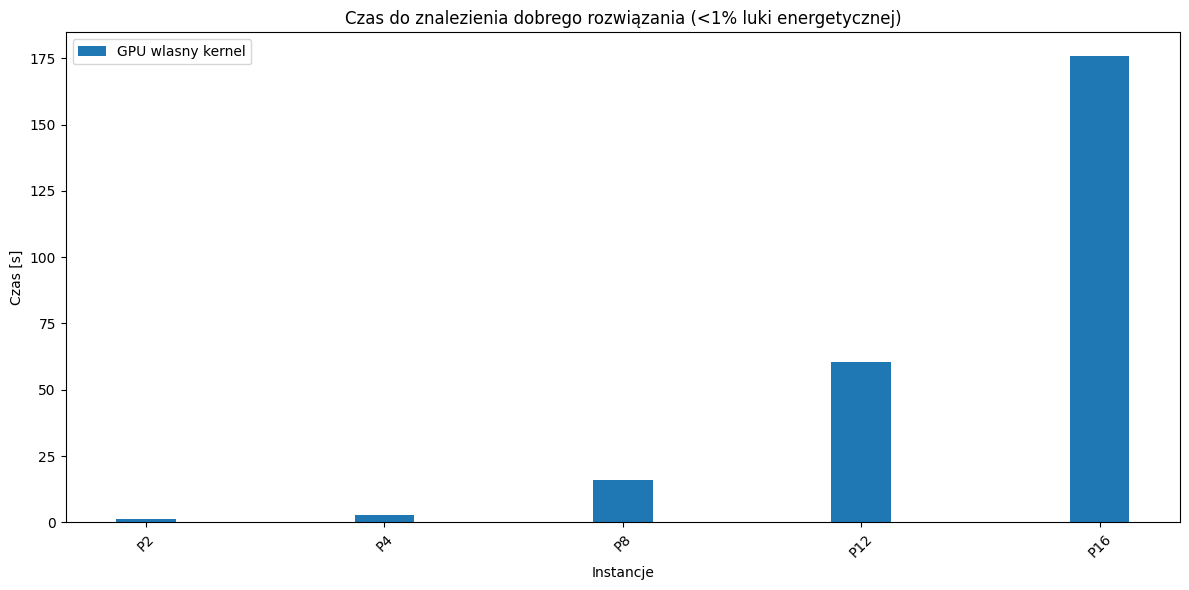

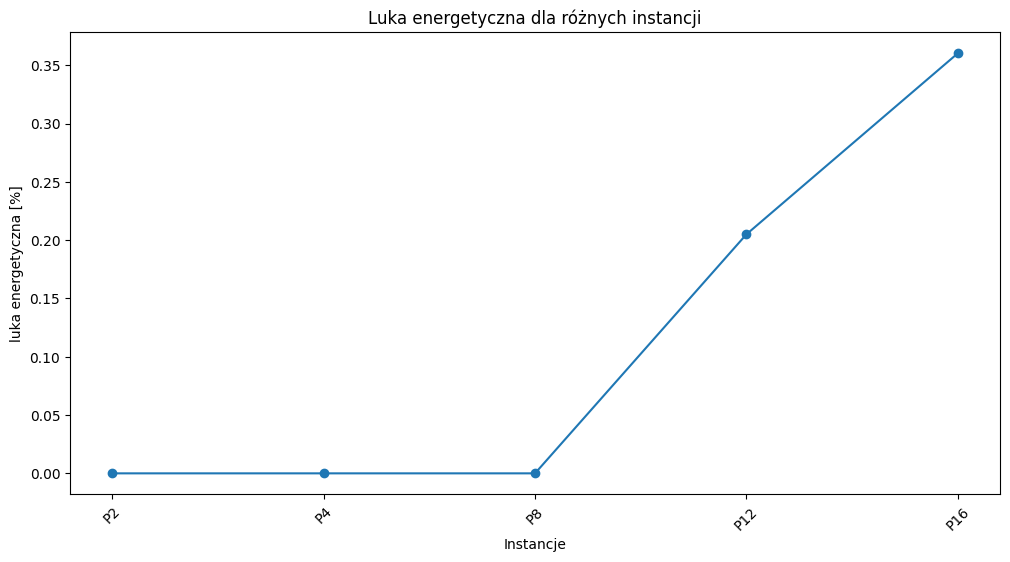

In [22]:
# Rysowanie wykresów

import os
import pickle

import matplotlib.pyplot as plt
import numpy as np


with open(os.path.join("wyniki", "sbm_pegasus_results.pkl"), "rb") as f:
    times, gaps = pickle.load(f)


instancje = ["P2", "P4", "P8", "P12", "P16"]

x = np.arange(len(instancje))
width = 0.25  

fig, ax = plt.subplots(figsize=(12, 6))

#rects2 = ax.bar(x, global_results[1], width, label='GPU naiwne')
rects3 = ax.bar(x, times, width, label='GPU wlasny kernel')

ax.set_xlabel("Instancje")
ax.set_ylabel("Czas [s]")
ax.set_title(r"Czas do znalezienia dobrego rozwiązania (<1% luki energetycznej)")
ax.set_xticks(x)
ax.set_xticklabels(instancje, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(12, 6))

gaps_procent = [x * 100 for x in gaps]
ax2.plot(x, gaps_procent, label='GPU wlasny kernel', marker='o', linestyle='-')
ax2.set_xlabel("Instancje")
ax2.set_ylabel("luka energetyczna [%]")
ax2.set_title("Luka energetyczna dla różnych instancji")
ax2.set_xticks(x)
ax2.set_xticklabels(instancje, rotation=45)
plt.show()

In [2]:
######
# Komórka WIP może nie działać
#####

import torch
import simulated_bifurcation as sb
import numpy as np
from funkcje_pomocnicze import read_instance, test_pegasus, ising_to_qubo, small_pegasus, full_pegasus
from benchmarks import discrete_simulated_bifurcation


J1, h1 = read_instance(full_pegasus.path, convention="dwave")

J1 = torch.tensor(J1, dtype=torch.float32)
h1 = torch.tensor(h1, dtype=torch.float32)


sb.minimize(J1, h1, domain="spin", dtype=torch.float32, agents=1000, mode="discrete")

🔁 Iterations       :   2%|▏         | 190/10000 [00:10<09:19, 17.53 steps/s]/home/tsmierzchalski/anaconda3/envs/szkolenia/lib/python3.12/site-packages/simulated_bifurcation/optimizer/simulated_bifurcation_optimizer.py:279: RuntimeWarning: Simulation interrupted by user. Current spins will be returned.
  spins = self.__symplectic_update(matrix, early_stopping)
🏁 Bifurcated agents:   0%|          | 0/1000 [00:10<?, ? agents/s]
/home/tsmierzchalski/anaconda3/envs/szkolenia/lib/python3.12/site-packages/simulated_bifurcation/optimizer/simulated_bifurcation_optimizer.py:281: ConvergenceWarning: No agent has converged. Returned signs of final positions instead.
  return self.get_final_spins(spins, early_stopping)


(tensor([ 1.,  1.,  1.,  ..., -1.,  1., -1.]), tensor(-10278.))

# Brute Force

Pierwsze kilka komórek tworzy dane potrzebne do benchmarku, a ostatnia rysuje wykres

In [ ]:
##############################
# Uruchom tą komurkę z kernelem "bruteforce"
##############################

# Tworzenie danych dla omnisolver-bruteforce

import time
import os
import pickle
import numpy as np
from dimod import BinaryQuadraticModel
from tqdm import tqdm
from omnisolver.bruteforce.gpu.sampler import BruteforceGPUSampler

sampler = BruteforceGPUSampler()

# Kompilacja jądra CUDA
suffix_size = 10
threadsperblock = 256
blockspergrid = 2**(suffix_size)//threadsperblock

Q = np.random.uniform(-1, 1, size=(10, 10))
Q = np.triu(Q)
bqm = BinaryQuadraticModel(Q, vartype="BINARY")
sampler.sample(bqm, num_states=10, suffix_size=suffix_size, grid_size=blockspergrid, 
                   block_size=threadsperblock, dtype=np.float32)


# utworzenie danych
times = []
for n in tqdm(range(10, 41)):
    Q = np.random.uniform(-1, 1, size=(n, n))
    Q = np.triu(Q)
    bqm = BinaryQuadraticModel(Q, vartype="BINARY")


    suffix_size = min(n, 21)
    threadsperblock = 512
    blockspergrid = 2**(suffix_size)//threadsperblock
    
    start = time.time()
    sampler.sample(bqm, num_states=10, suffix_size=suffix_size, grid_size=blockspergrid, 
                   block_size=threadsperblock, dtype=np.float32)
    end = time.time()
    times.append(end - start)

with open(os.path.join("wyniki", "omnisolver_bruteforce_results.pkl"), "wb") as f:
    pickle.dump(times, f)


100%|██████████| 31/31 [08:04<00:00, 15.64s/it] 


In [ ]:
# Tworzenie danych dla naszej implementacji na GPU

import time
import os
import pickle
import cupy as cp

from benchmarks import brute_force_gpu
from tqdm import tqdm
from IPython.utils.io import capture_output

# Kompilacja
Q = cp.random.uniform(-1, 1, size=(10, 10), dtype=cp.float32)
Q = cp.triu(Q)
brute_force_gpu(Q, 10)

times = []
for n in tqdm(range(10, 41)):
    Q = cp.random.uniform(-1, 1, size=(n, n), dtype=cp.float32)
    Q = cp.triu(Q)
    start = time.time()
    with capture_output() as captured:
        brute_force_gpu(Q, num_states=10, sweep_size_exponent=min(n, 21), threadsperblock=512)
    end = time.time()
    times.append(end - start)

with open(os.path.join("wyniki", "bruteforce_results.pkl"), "wb") as f:
    pickle.dump(times, f)

100%|██████████| 31/31 [37:49<00:00, 73.21s/it] 


In [ ]:
# Tworzenie danych dla naiwnej implementacji na CPU

import time
import os
import pickle
import numpy as np

from benchmarks import brute_force_naive
from tqdm import tqdm
from IPython.utils.io import capture_output


times = []
n_range = list(range(10, 27))
for n in tqdm(n_range, desc="Wyczerpujące przeszukiwanie dla różnych n"):

    J = np.triu(np.random.uniform(-1, 1, size=(n, n)), k=1)  # losowa gęsta macierz górnotrójkątna
    h = np.random.uniform(-1, 1, size=n)  # losowy wektor
    start = time.time()
    with capture_output() as captured:
        state, energy = brute_force_naive(J, h)
    end = time.time()
    elapsed = end - start
    times.append(elapsed)

with open(os.path.join("wyniki", "bruteforce_cpu_results.pkl"), "wb") as f:
    pickle.dump(times, f)

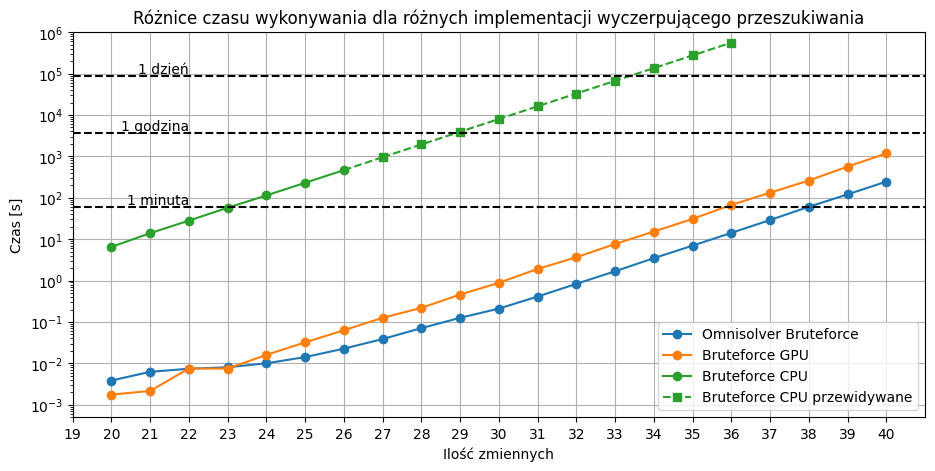

In [36]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

with open(os.path.join("wyniki", "bruteforce_results.pkl"), "rb") as f:
    times_bf = pickle.load(f)

with open(os.path.join("wyniki", "omnisolver_bruteforce_results.pkl"), "rb") as f:
    times_omnisolver = pickle.load(f)

with open(os.path.join("wyniki", "bruteforce_cpu_results.pkl"), "rb") as f:
    times_bf_cpu = pickle.load(f)

# Predykcja wartości dla CPU
x = np.array(list(range(20, 27))).reshape(-1, 1)
y = np.log(times_bf_cpu[10:])
model = LinearRegression().fit(x, y)

x_extended = np.arange(27, 37).reshape(-1, 1)
y_log_pred = model.predict(x_extended)
y_pred = np.exp(y_log_pred)

x1 = list(range(20, 41))
x2 = list(range(20, 41))
x3 = list(range(20, 27))

minute = 60
hour = 60 * 60
day = 60 * 60 * 24

plt.figure(figsize=(11, 5))
plt.plot(x1, times_omnisolver[10:], label='Omnisolver Bruteforce', marker='o', linestyle='-')
plt.plot(x2, times_bf[10:], label='Bruteforce GPU', marker='o', linestyle='-')
plt.plot(x3, times_bf_cpu[10:], label='Bruteforce CPU', marker='o', linestyle='-')
plt.plot([26, 27], [times_bf_cpu[16], y_pred[0]], linestyle='--', color='#2ca02c')
plt.plot(x_extended, y_pred, label="Bruteforce CPU przewidywane", marker="s", linestyle="--", color="#2ca02c")

plt.xticks([19] + list(range(20, 41)))
plt.yscale('log', base=10)
plt.ylim(5 * 10**-4, 10**6)

plt.axhline(minute, color='black', linestyle='--')
plt.axhline(hour, color='black', linestyle='--')
plt.axhline(day, color='black', linestyle='--')

x_min, x_max = plt.xlim()
x_label = x_min + 3

# Add text labels above the lines
plt.text(x_label, minute, '1 minuta', color='black', va='bottom', ha='right')
plt.text(x_label, hour, '1 godzina', color='black', va='bottom', ha='right')
plt.text(x_label, day, '1 dzień', color='black', va='bottom', ha='right')


plt.xlabel('Ilość zmiennych')
plt.ylabel('Czas [s]')
plt.title('Różnice czasu wykonywania dla różnych implementacji wyczerpującego przeszukiwania')
plt.legend()
plt.grid(True)
plt.show()

Jak widać z wykresu, naiwna implementacja nawet stosunkowo małych problemów (34 zmienne) staje się bezużyteczna. Warto zauważyć, że nasza implementacja nie odstaje aż tak drastycznie od bardzo zoptymalizowanej. 